# Plotly + Dash Tutorial — Jupyter Notebook Edition

A half-day deep dive for learning Plotly and Dash from scratch, with a focus on **data analysis dashboards** (filters, stats, linked views).

**Structure**
1. Plotly Express basics
2. Plotly Graph Objects
3. Figure customization & subplots
4. Your first Dash app in Jupyter
5. Core Dash components
6. **Callbacks deep-dive** (the long section)
7. Capstone: a Gapminder data-analysis dashboard
8. Next steps

Exercises are marked 🧩 and have no written solutions — figure them out yourself.

## 1. Setup

If you don't already have the packages installed, uncomment and run the cell below.
`dash` (≥ 2.11) includes Jupyter support natively — no separate `jupyter-dash` package needed.

In [1]:
# !pip install dash

In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import dash
from dash import Dash, html, dcc, callback, Input, Output, State, no_update, ctx
from dash.exceptions import PreventUpdate

import plotly, dash as dash_pkg
print(f"plotly  = {plotly.__version__}")
print(f"dash    = {dash_pkg.__version__}")
print(f"pandas  = {pd.__version__}")

plotly  = 6.7.0
dash    = 4.1.0
pandas  = 3.0.2


## 2. Plotly Express basics

`plotly.express` (usually imported as `px`) is the high-level API. One function call → one interactive figure.
It covers the ~80% case: scatter, line, bar, histogram, box, heatmap, choropleth, and more.

Every `px` function returns a `plotly.graph_objects.Figure` object, which you can then tweak.

We'll use three built-in datasets throughout:
- **`tips`** — restaurant bills (small, great for categorical plots)
- **`iris`** — classic flower measurements
- **`gapminder`** — country-level stats over time (our capstone dataset)

In [3]:
tips = px.data.tips()
iris = px.data.iris()
gapminder = px.data.gapminder()

print("tips:", tips.shape)
tips.head()

tips: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
print("iris:", iris.shape)
iris.head()

iris: (150, 6)


,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [5]:
print("gapminder:", gapminder.shape)
gapminder.head()

gapminder: (1704, 8)


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


### 2.1 Scatter

The simplest chart. Map columns to visual channels: `x`, `y`, `color`, `size`, `symbol`, `hover_data`.

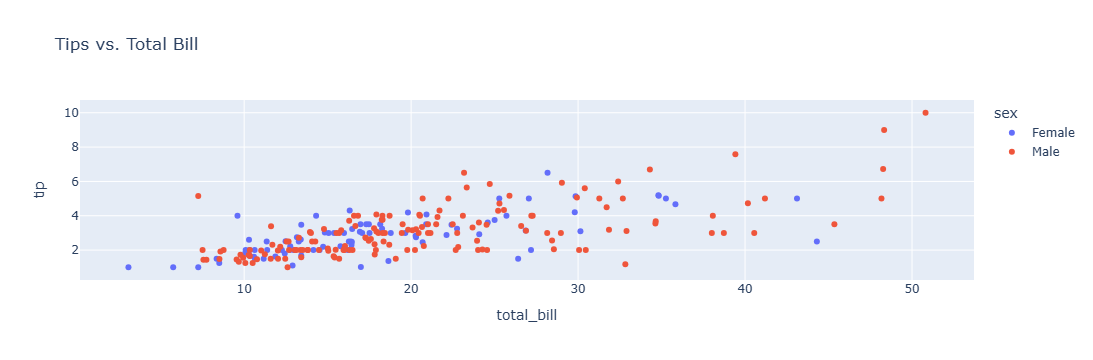

In [6]:
fig = px.scatter(
    tips,
    x="total_bill",
    y="tip",
    color="sex",
    hover_data=["day", "time"],
    title="Tips vs. Total Bill",
)
fig.show()

### 2.2 Line

Lines need an ordered x-axis — usually time. Let's track Germany and Japan in the gapminder data.

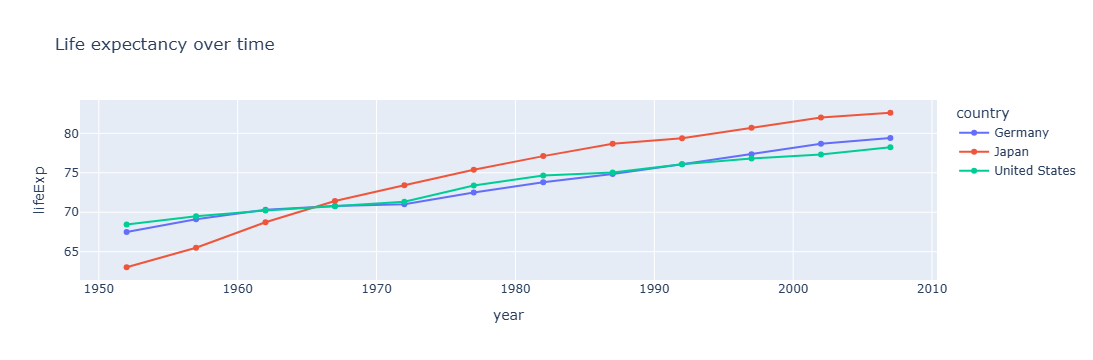

In [7]:
subset = gapminder.query("country in ['Germany', 'Japan', 'United States']")

fig = px.line(
    subset,
    x="year",
    y="lifeExp",
    color="country",
    markers=True,
    title="Life expectancy over time",
)
fig.show()

### 2.3 Bar

Bars compare magnitudes across categories. `barmode` controls stacked vs. grouped.

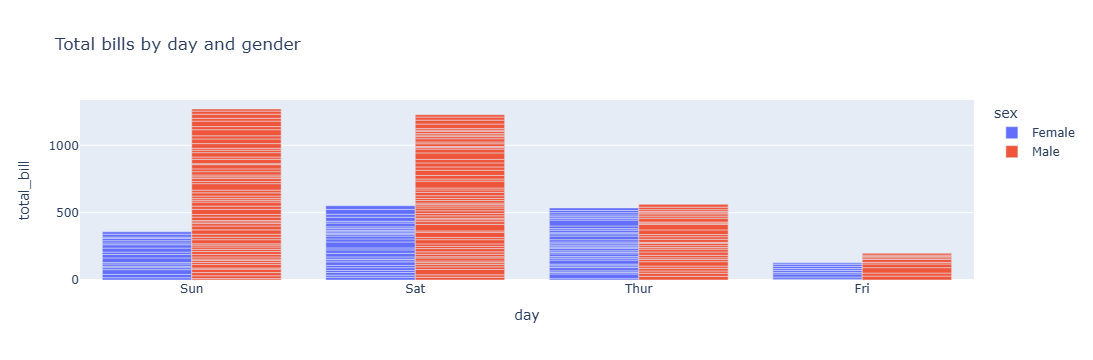

In [8]:
fig = px.bar(
    tips,
    x="day",
    y="total_bill",
    color="sex",
    barmode="group",
    title="Total bills by day and gender",
)
fig.show()

### 2.4 Histogram

Histograms bin a continuous variable. `nbins` controls resolution; `marginal` adds a small companion plot.

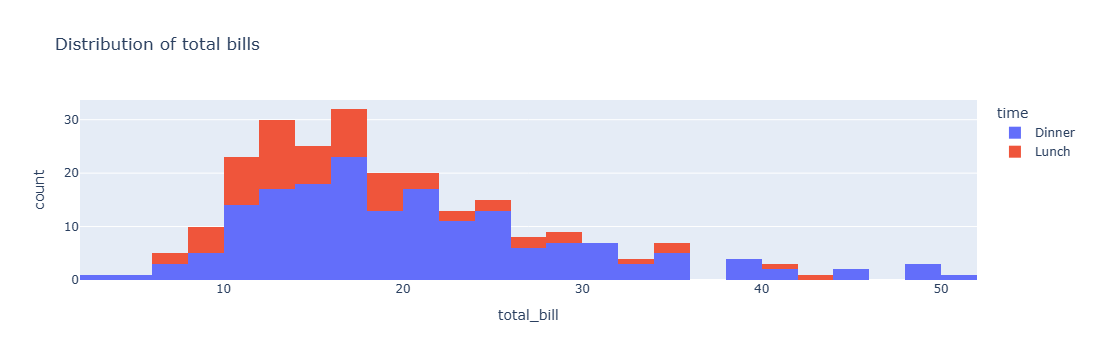

In [9]:
fig = px.histogram(
    tips,
    x="total_bill",
    color="time",
    nbins=30,
    title="Distribution of total bills",
)
fig.show()

### 2.5 Box plot

Good for comparing distributions across categories. `points="all"` overlays the raw data.

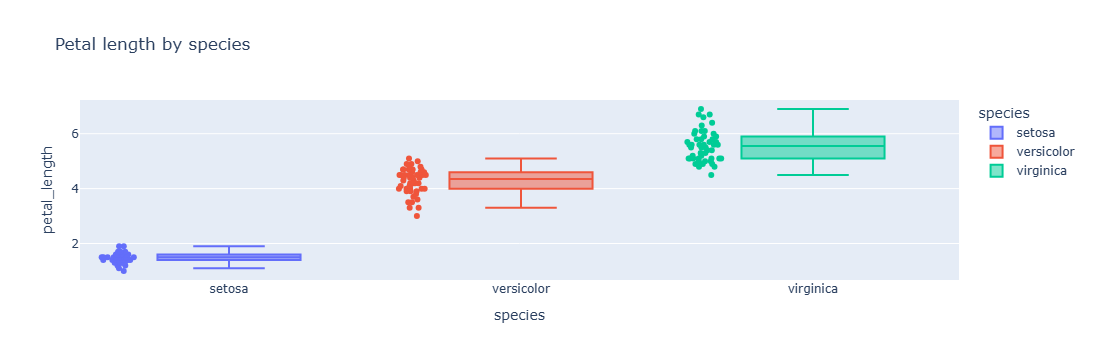

In [10]:
fig = px.box(
    iris,
    x="species",
    y="petal_length",
    color="species",
    points="all",
    title="Petal length by species",
)
fig.show()

### 🧩 Exercise 2

Using the `gapminder` dataset:
1. Make a scatter of `gdpPercap` vs. `lifeExp` for the year **2007**, colored by `continent` and sized by `pop`.
2. Set the x-axis to log scale (hint: `log_x=True`).
3. Add `hover_name="country"` so hovering shows the country name prominently.

## 3. Plotly Graph Objects

When Express isn't flexible enough — mixing chart types, custom traces, fine-grained control — drop down to **Graph Objects** (`go`).

Mental model:
- A `Figure` has a list of **traces** (`fig.data`) and a **layout** (`fig.layout`).
- Each trace is something like `go.Scatter`, `go.Bar`, `go.Box`.
- You add traces with `fig.add_trace(...)` or pass them in at construction.

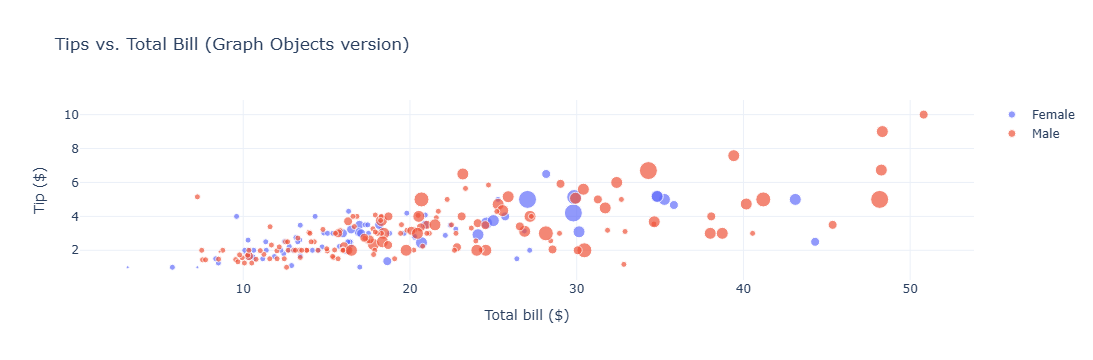

In [11]:
# Same tips scatter, but built with go
fig = go.Figure()

for sex in tips["sex"].unique():
    sub = tips[tips["sex"] == sex]
    fig.add_trace(go.Scatter(
        x=sub["total_bill"],
        y=sub["tip"],
        mode="markers",
        name=sex,
        marker=dict(size=sub["size"] * 3),
    ))

fig.update_layout(
    title="Tips vs. Total Bill (Graph Objects version)",
    xaxis_title="Total bill ($)",
    yaxis_title="Tip ($)",
    template="plotly_white",
)
fig.show()

Notice how much more code that is. That's the trade-off: `px` is concise, `go` is flexible.

In practice: **start with `px`, then refine using `fig.update_*` methods**. Every `px` figure is a real `go.Figure` underneath.

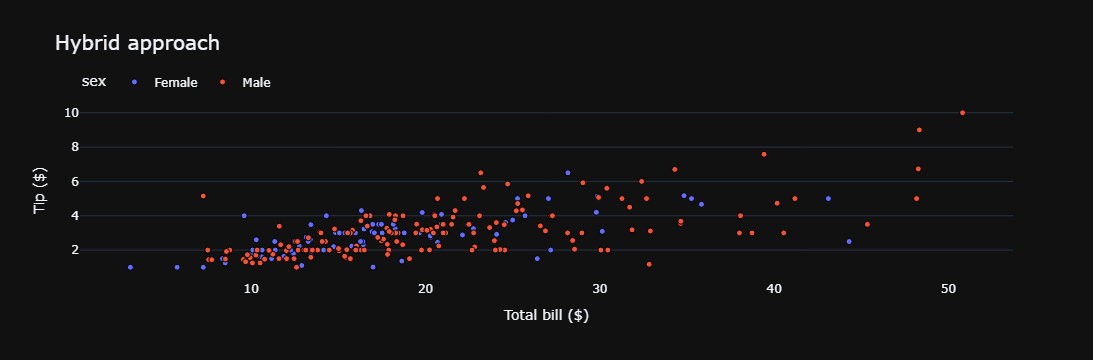

In [12]:
# Starting from px, then customizing
fig = px.scatter(tips, x="total_bill", y="tip", color="sex", title="Hybrid approach")

fig.update_traces(marker=dict(line=dict(width=1, color="black")))
fig.update_layout(
    template="plotly_dark",
    title_font_size=20,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.update_xaxes(title="Total bill ($)", showgrid=False)
fig.update_yaxes(title="Tip ($)", zeroline=True, zerolinecolor="gray")

fig.show()

### Built-in themes

Try: `plotly`, `plotly_white`, `plotly_dark`, `ggplot2`, `seaborn`, `simple_white`, `presentation`, `none`.

In [13]:
import plotly.io as pio
print(list(pio.templates))

['ggplot2', 'seaborn', 'simple_white', 'plotly', 'plotly_white', 'plotly_dark', 'presentation', 'xgridoff', 'ygridoff', 'gridon', 'none']


### 🧩 Exercise 3

Take the `iris` box plot from section 2.5 and rebuild it using **only Graph Objects** (`go.Box`). One trace per species. Bonus: set a different `marker_color` for each species.

## 4. Figure customization & subplots

Three things you'll reach for constantly:

1. **Hover templates** — control what appears on hover
2. **Annotations & shapes** — highlight specific points or regions
3. **Subplots** — multiple charts in one figure

### 4.1 Hover templates

`%{x}`, `%{y}`, `%{customdata[0]}` refer to the trace's data. `<extra></extra>` hides the trace name box.

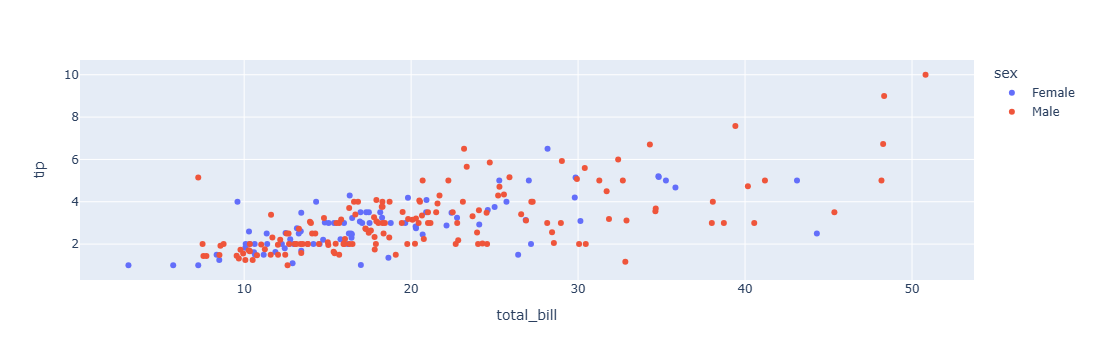

In [14]:
fig = px.scatter(tips, x="total_bill", y="tip", color="sex",
                 custom_data=["day", "size"])

fig.update_traces(hovertemplate=(
    "<b>Bill:</b> $%{x:.2f}<br>"
    "<b>Tip:</b> $%{y:.2f}<br>"
    "<b>Day:</b> %{customdata[0]}<br>"
    "<b>Party size:</b> %{customdata[1]}<br>"
    "<extra></extra>"
))
fig.show()

### 4.2 Annotations

Useful for pointing out specific data points or periods.

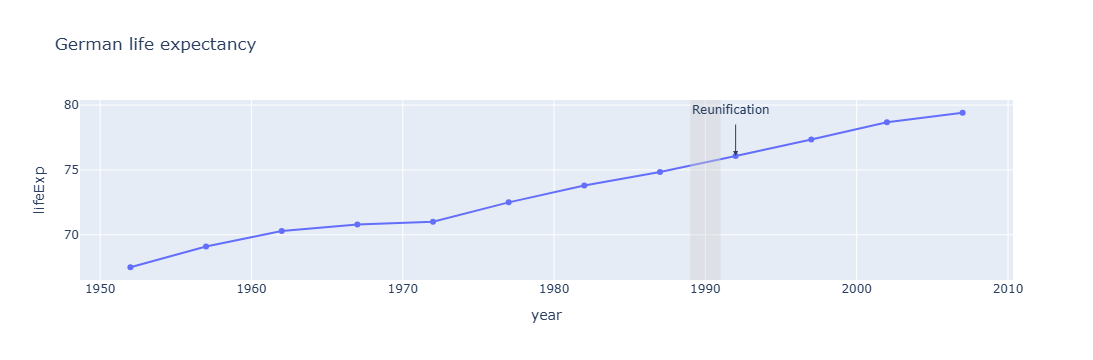

In [15]:
de = gapminder.query("country == 'Germany'")

fig = px.line(de, x="year", y="lifeExp", markers=True,
              title="German life expectancy")

fig.add_annotation(
    x=1992, y=de.query("year == 1992")["lifeExp"].iloc[0],
    showarrow=True, arrowhead=2, ax=0, ay=-40,
)
fig.add_vrect(x0=1989, x1=1991, fillcolor="lightgray",
              opacity=0.4, line_width=0,
              annotation_text="Reunification", annotation_position="top left")

fig.show()

### 4.3 Subplots

Two approaches:

- **`px` with faceting** — `facet_row` / `facet_col` for the same chart repeated across a categorical variable
- **`make_subplots`** — mix *different* chart types

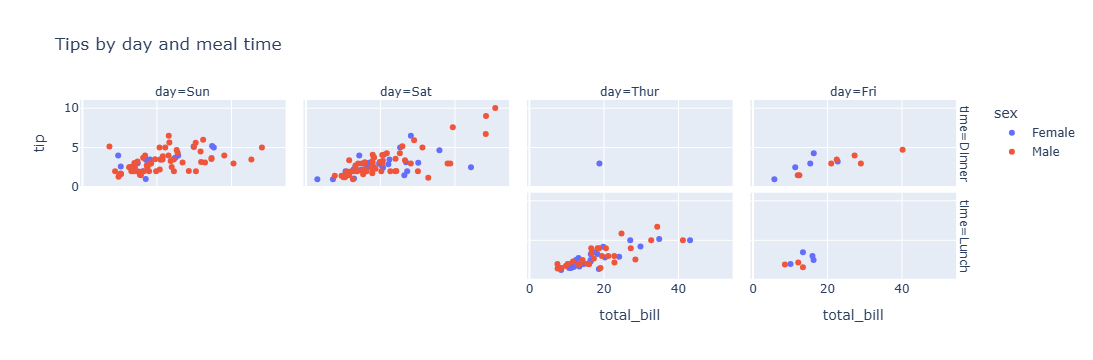

In [16]:
# Faceting with px (easy)
fig = px.scatter(tips, x="total_bill", y="tip",
                 color="sex", facet_col="day", facet_row="time",
                 title="Tips by day and meal time")
fig.show()

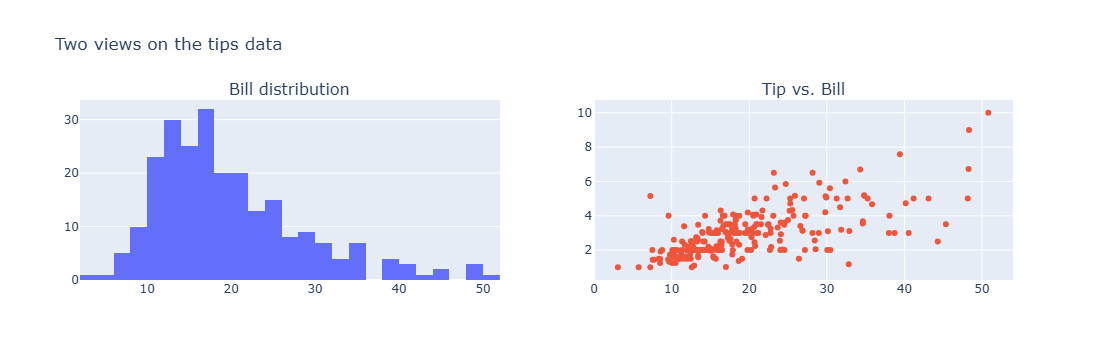

In [17]:
# make_subplots (flexible) — different chart types side by side
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Bill distribution", "Tip vs. Bill"))

fig.add_trace(
    go.Histogram(x=tips["total_bill"], name="Bills"),
    row=1, col=1,
)
fig.add_trace(
    go.Scatter(x=tips["total_bill"], y=tips["tip"],
               mode="markers", name="Tips"),
    row=1, col=2,
)

fig.update_layout(title_text="Two views on the tips data", showlegend=False)
fig.show()

### 🧩 Exercise 4

Build a **2×2 subplot figure** using `make_subplots` with the `iris` dataset:
- Top-left: histogram of `sepal_length`
- Top-right: histogram of `petal_length`
- Bottom-left: scatter of `sepal_length` vs `sepal_width`
- Bottom-right: scatter of `petal_length` vs `petal_width`

Give it a single overall title. Bonus: color the scatters by `species`.

## 5. Your first Dash app in Jupyter

**What Dash is:** a Python framework for building web dashboards. Under the hood it's React + Flask, but you write only Python.

**Three pieces of any Dash app:**
1. **`app = Dash(__name__)`** — the app instance
2. **`app.layout`** — what the page looks like (a tree of components)
3. **Callbacks** — Python functions that update components based on user input (next sections)

Since Dash 2.11, you can run apps inline in a notebook with `app.run(jupyter_mode="inline")`.

In [18]:
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Hello, Dash!"),
    html.P("This is my first Dash app running inside a Jupyter notebook."),
    dcc.Graph(
        figure=px.scatter(iris, x="sepal_length", y="sepal_width",
                          color="species", title="Iris sepals"),
    ),
])

app.run(jupyter_mode="inline", port=8050, debug=False)

### Jupyter run modes

`app.run(jupyter_mode=...)` accepts:

| Mode | Behavior |
|------|----------|
| `"inline"` | Render inside the notebook cell output (default here) |
| `"external"` | Print a URL to open in your browser |
| `"tab"` | Open a new browser tab automatically |
| `"jupyterlab"` | Open in a JupyterLab side pane |

**Port conflicts:** each app uses a port (default `8050`). In this notebook we'll increment the port (`8050`, `8051`, …) so you can re-run any cell without stopping earlier ones. In your own projects, reuse `8050` and just re-run.

**Stopping an app:** currently there's no clean programmatic stop — restarting the kernel is the nuclear option. For most iterative work, just re-run the cell; Dash will replace the running app.

### 🧩 Exercise 5

Modify the app above:
1. Add a second `dcc.Graph` below the first, showing a **box plot** of `petal_length` by `species`.
2. Wrap both graphs in an `html.Div` with `style={"display": "flex"}` so they sit side-by-side.
3. Add an `html.H2` subtitle between the H1 and the graphs.

## 6. Core Dash components

Dash components live in two modules:

- **`dash.html`** — HTML wrappers (`html.Div`, `html.H1`, `html.P`, `html.Button`, …)
- **`dash.dcc`** — interactive components (`dcc.Graph`, `dcc.Dropdown`, `dcc.Slider`, …)

Every component has an **`id`** (string) that callbacks use to reference it. IDs must be unique within the app.

The following cell is a **static layout** showcasing the components you'll use most. There are no callbacks yet — nothing reacts to input — we're just seeing what they render.

In [19]:
app = Dash(__name__)

continents = sorted(gapminder["continent"].unique())
years = sorted(gapminder["year"].unique())

app.layout = html.Div(style={"fontFamily": "sans-serif", "padding": "20px", "maxWidth": "700px"}, children=[
    html.H2("Core Dash components"),

    html.Label("Dropdown (single-select)"),
    dcc.Dropdown(
        id="demo-dropdown",
        options=[{"label": c, "value": c} for c in continents],
        value="Europe",
    ),
    html.Br(),

    html.Label("Dropdown (multi-select)"),
    dcc.Dropdown(
        id="demo-dropdown-multi",
        options=continents,          # shorthand: list of strings
        value=["Europe", "Asia"],
        multi=True,
    ),
    html.Br(),

    html.Label("Slider"),
    dcc.Slider(
        id="demo-slider",
        min=min(years), max=max(years), step=5,
        value=2007,
        marks={y: str(y) for y in years},
    ),
    html.Br(),

    html.Label("RangeSlider"),
    dcc.RangeSlider(
        id="demo-range",
        min=min(years), max=max(years), step=5,
        value=[1977, 2007],
        marks={y: str(y) for y in years},
    ),
    html.Br(),

    html.Label("Checklist"),
    dcc.Checklist(
        id="demo-checklist",
        options=continents,
        value=["Europe", "Americas"],
        inline=True,
    ),
    html.Br(),

    html.Label("RadioItems"),
    dcc.RadioItems(
        id="demo-radio",
        options=["lifeExp", "gdpPercap", "pop"],
        value="lifeExp",
        inline=True,
    ),
    html.Br(),

    html.Label("Text input"),
    dcc.Input(id="demo-input", type="text", placeholder="Type something..."),
    html.Br(), html.Br(),

    html.Button("A button", id="demo-button", n_clicks=0),
])

app.run(jupyter_mode="inline", port=8051, debug=False)

### Component patterns worth remembering

- **`options`** can be a list of strings *or* a list of `{"label": ..., "value": ...}` dicts. The dict form lets the displayed label differ from the stored value.
- **`value`** is the *current* selection. For multi-select / checklist, it's a list.
- **`n_clicks`** on buttons starts at 0 and increments on every click — the standard way to detect "was the button pressed?"
- **`html.Br()`** inserts a line break; use CSS via `style={...}` for real layout.

### 🧩 Exercise 6

Build a static layout (no callbacks) that contains:
1. An `html.H1` title
2. A `dcc.Dropdown` with the list of iris species
3. A `dcc.RangeSlider` for `petal_length` values (min/max from the data)
4. A `dcc.Graph` showing *any* iris chart of your choice

Don't worry about making anything interactive yet.

## 7. Callback anatomy — the deep dive

This is the part of Dash that trips people up. Read this section slowly.

### What a callback is

A callback is a Python function that Dash runs automatically whenever an input component's value changes. The function's return value gets written into an output component's property.

### The syntax

```python
@callback(
    Output("output-id", "property"),
    Input("input-id", "property"),
)
def my_function(input_value):
    # ... compute something ...
    return new_output_value
```

### What each piece means

- **`Output("output-id", "property")`** — when the function returns, Dash sets `component.property` on the component whose `id` is `"output-id"`.
- **`Input("input-id", "property")`** — Dash watches `component.property` on that input component. Whenever it changes, the callback fires.
- **The function's arguments** are passed in the same order as the `Input(...)`s declared above.
- **The function's return value** is assigned to the `Output`. If you declare multiple outputs, return a tuple.

### What Dash actually does under the hood

1. On page load, Dash walks your layout and identifies every component with an `id`.
2. It builds a dependency graph: "`output-id.property` depends on `input-id.property`".
3. When a user interacts (e.g., picks a dropdown option), the browser sends the new value to the Python backend.
4. Python runs your callback function with that value.
5. The return value is sent back to the browser and applied to the output component.
6. If that output is itself an input to another callback, *that* callback fires too — this is how **chained callbacks** work.

### Important rules

- **Every output can have at most one callback writing to it.** (Well — there's `allow_duplicate=True`, but start simple.)
- **Callbacks can't have side effects** you rely on. They might run multiple times, in any order. Always return the new state; don't mutate globals.
- **A callback fires once at startup** with the initial input values (unless you set `prevent_initial_call=True`).

We'll make all of this concrete with examples. Ready?

## 8. Callbacks: Single Input → Single Output

The classic pattern: a dropdown controls a chart.

In [20]:
app = Dash(__name__)

app.layout = html.Div([
    html.H3("Gapminder by continent — 2007"),
    dcc.Dropdown(
        id="continent-picker",
        options=sorted(gapminder["continent"].unique()),
        value="Europe",
    ),
    dcc.Graph(id="life-vs-gdp"),
])


@callback(
    Output("life-vs-gdp", "figure"),     # set .figure on the dcc.Graph
    Input("continent-picker", "value"),  # watch .value on the dropdown
)
def update_chart(selected_continent):
    df = gapminder.query("year == 2007 and continent == @selected_continent")
    fig = px.scatter(
        df, x="gdpPercap", y="lifeExp",
        size="pop", hover_name="country", log_x=True,
        title=f"Life expectancy vs. GDP — {selected_continent}, 2007",
    )
    return fig


app.run(jupyter_mode="inline", port=8052, debug=False)

**Line-by-line:**

- `@callback(...)` registers the function with Dash. You can equivalently write `@app.callback(...)` — both work.
- `Output("life-vs-gdp", "figure")` — target: the `figure` property of the component with id `"life-vs-gdp"` (our `dcc.Graph`).
- `Input("continent-picker", "value")` — source: the `value` property of the dropdown.
- `def update_chart(selected_continent)` — the argument receives the current dropdown value. Name it whatever you like; order matches the `Input(...)`s.
- `return fig` — Dash assigns this to `dcc.Graph.figure`, which re-renders the chart.

Change the dropdown; the chart updates. That's the whole loop.

## 9. Callbacks: Multiple Inputs → Single Output

Add more `Input(...)`s. Arguments match their order.

In [21]:
app = Dash(__name__)

app.layout = html.Div([
    html.H3("Gapminder — continent + year"),
    html.Label("Continent"),
    dcc.Dropdown(
        id="cont-2",
        options=sorted(gapminder["continent"].unique()),
        value="Europe",
    ),
    html.Label("Year"),
    dcc.Slider(
        id="year-2",
        min=1952, max=2007, step=5, value=2007,
        marks={y: str(y) for y in sorted(gapminder["year"].unique())},
    ),
    dcc.Graph(id="chart-2"),
])


@callback(
    Output("chart-2", "figure"),
    Input("cont-2", "value"),
    Input("year-2", "value"),
)
def update(continent, year):
    df = gapminder.query("continent == @continent and year == @year")
    fig = px.scatter(df, x="gdpPercap", y="lifeExp",
                     size="pop", hover_name="country", log_x=True,
                     title=f"{continent}, {year}")
    return fig


app.run(jupyter_mode="inline", port=8053, debug=False)

Changing **either** control fires the callback. Both values are always passed in — Dash doesn't tell you (by default) which one actually changed.

## 10. Callbacks: Single Input → Multiple Outputs

Return a **tuple** matching the declared outputs.

In [22]:
app = Dash(__name__)

app.layout = html.Div([
    html.H3("One control, two charts"),
    dcc.Dropdown(
        id="cont-3",
        options=sorted(gapminder["continent"].unique()),
        value="Europe",
    ),
    html.Div([
        dcc.Graph(id="chart-3a", style={"width": "50%"}),
        dcc.Graph(id="chart-3b", style={"width": "50%"}),
    ], style={"display": "flex"}),
])


@callback(
    Output("chart-3a", "figure"),
    Output("chart-3b", "figure"),
    Input("cont-3", "value"),
)
def update(continent):
    df = gapminder.query("continent == @continent and year == 2007")

    scatter = px.scatter(df, x="gdpPercap", y="lifeExp", size="pop",
                         hover_name="country", log_x=True,
                         title=f"{continent} — 2007")

    bar = px.bar(df.nlargest(10, "pop"),
                 x="country", y="pop",
                 title=f"Top 10 by population — {continent}")

    return scatter, bar


app.run(jupyter_mode="inline", port=8054, debug=False)

### 🧩 Exercise 10

Modify the app above:
1. Add a **third output** — an `html.Div` with id `"stats"` that displays the mean life expectancy and total population for the selected continent in 2007.
2. Format the text nicely (e.g., `"Europe 2007 — avg life exp: 77.6 yrs, total pop: 586M"`).

Hint: to update a `html.Div`'s text, use the `children` property.

## 11. `State` vs `Input`

Both read a component's value. The difference is **when the callback fires**.

- **`Input(...)`** — changing this value *triggers* the callback
- **`State(...)`** — reads the value but does *not* trigger the callback

The classic use case: a form with several fields and a Submit button. You want the callback to fire **only** on submit, with all the fields' current values available.

In [23]:
app = Dash(__name__)

app.layout = html.Div([
    html.H3("Form with submit button"),
    html.Label("Your name:"),
    dcc.Input(id="form-name", type="text", value=""),
    html.Br(), html.Br(),
    html.Label("Favorite continent:"),
    dcc.Dropdown(id="form-cont",
                 options=sorted(gapminder["continent"].unique()),
                 value="Europe"),
    html.Br(),
    html.Button("Submit", id="form-submit", n_clicks=0),
    html.Div(id="form-output", style={"marginTop": "20px", "fontSize": "18px"}),
])


@callback(
    Output("form-output", "children"),
    Input("form-submit", "n_clicks"),     # the TRIGGER
    State("form-name", "value"),          # read but don't trigger
    State("form-cont", "value"),          # read but don't trigger
    prevent_initial_call=True,            # don't fire on page load
)
def on_submit(n_clicks, name, continent):
    if not name:
        return "Please enter a name."
    return f"Hi {name}! You picked {continent}."


app.run(jupyter_mode="inline", port=8055, debug=False)

Typing in the name field doesn't do anything. Changing the dropdown doesn't do anything. Only clicking Submit fires the callback — and at that moment, the callback sees the *current* values of the name and continent fields via `State`.

**`prevent_initial_call=True`** stops Dash from firing the callback once at page load with `n_clicks=0`. Handy for submit buttons.

## 12. `callback_context` — which input fired?

Sometimes multiple inputs can trigger the same callback and you need to know **which one** triggered it. Example: a "reset" button that sets things back to defaults.

Dash provides `ctx` (short for `callback_context`). Its key property is `ctx.triggered_id` — the `id` of the component that fired.

In [24]:
app = Dash(__name__)

app.layout = html.Div([
    html.H3("Which button did you press?"),
    html.Button("Button A", id="btn-a", n_clicks=0),
    html.Button("Button B", id="btn-b", n_clicks=0),
    html.Button("Reset", id="btn-reset", n_clicks=0),
    html.Div(id="which", style={"marginTop": "20px", "fontSize": "18px"}),
])


@callback(
    Output("which", "children"),
    Input("btn-a", "n_clicks"),
    Input("btn-b", "n_clicks"),
    Input("btn-reset", "n_clicks"),
    prevent_initial_call=True,
)
def which_button(a, b, r):
    triggered = ctx.triggered_id
    if triggered == "btn-reset":
        return "Reset pressed."
    return f"{triggered} was pressed."


app.run(jupyter_mode="inline", port=8056, debug=False)

`ctx.triggered_id` is `None` on the initial load (which we skip via `prevent_initial_call`). On any subsequent trigger, it's the `id` string of the component that fired.

For pattern-matching callbacks (which we don't cover here) `ctx.triggered_id` returns a dict instead of a string.

## 13. Chained callbacks — dynamic dropdown options

When one callback's output is another callback's input, Dash chains them automatically. A common example: picking a continent should update the list of countries shown in a second dropdown.

In [25]:
app = Dash(__name__)

app.layout = html.Div([
    html.H3("Chained dropdowns"),
    html.Label("Continent"),
    dcc.Dropdown(
        id="chain-cont",
        options=sorted(gapminder["continent"].unique()),
        value="Europe",
    ),
    html.Label("Country"),
    dcc.Dropdown(id="chain-country"),  # options + value filled by callback
    dcc.Graph(id="chain-chart"),
])


# Callback 1: continent -> country options + default value
@callback(
    Output("chain-country", "options"),
    Output("chain-country", "value"),
    Input("chain-cont", "value"),
)
def set_country_options(continent):
    countries = sorted(gapminder.query("continent == @continent")["country"].unique())
    return countries, countries[0]   # default to the first one


# Callback 2: country -> chart
@callback(
    Output("chain-chart", "figure"),
    Input("chain-country", "value"),
)
def update_country_chart(country):
    if not country:
        raise PreventUpdate
    df = gapminder.query("country == @country")
    return px.line(df, x="year", y="lifeExp",
                   title=f"Life expectancy — {country}", markers=True)


app.run(jupyter_mode="inline", port=8057, debug=False)

**What happens when you pick "Asia":**

1. `set_country_options` fires → sets `chain-country.options` (the Asian countries) and `chain-country.value` (defaults to the first one).
2. Because `chain-country.value` changed, `update_country_chart` fires → updates the chart.

Two callbacks in sequence, wired automatically via the dependency graph.

## 14. Common callback pitfalls

### 14.1 `PreventUpdate`

Raise this to tell Dash "don't update anything this time". Useful when inputs are in an invalid state (e.g., empty).

```python
from dash.exceptions import PreventUpdate

@callback(Output("out", "children"), Input("inp", "value"))
def f(v):
    if not v:
        raise PreventUpdate   # output stays as-is
    return v.upper()
```

### 14.2 `no_update`

Like `PreventUpdate`, but per-output — useful with multiple outputs when you want to update some but not others.

```python
from dash import no_update

@callback(
    Output("out-1", "children"),
    Output("out-2", "children"),
    Input("inp", "value"),
)
def f(v):
    if v is None:
        return no_update, no_update
    return v, v.upper()
```

### 14.3 One output, one callback

By default, each output property can only be written by **one** callback. Trying to have two callbacks both target `Output("x", "value")` is a startup error. The escape hatch is `Output("x", "value", allow_duplicate=True)` plus `prevent_initial_call=True` on the callbacks — but if you find yourself reaching for this, it's often a sign to consolidate into one callback.

### 14.4 Circular dependencies

If callback A outputs to something callback B reads as an input, and callback B outputs to something callback A reads as an input — Dash will refuse to start. Redesign so data flows one direction.

### 14.5 Callback fires at startup

By default, every callback fires once on page load with initial values. Usually harmless; occasionally annoying. Three options:
- Accept it and write the callback to handle initial values correctly.
- Set `prevent_initial_call=True`.
- Raise `PreventUpdate` conditionally inside the function.

### 14.6 `n_clicks` starts at 0 (not `None`)

So `if n_clicks:` is `False` before the first click. That's usually what you want.

### 14.7 Component `id`s must be unique

Duplicate IDs are a silent source of weirdness. If a callback suddenly targets the wrong thing, check your IDs.

## 15. Capstone: a Gapminder data-analysis dashboard

Everything comes together here. Features:

- **Year slider** — pick any year
- **Continent multi-select** — filter continents
- **Metric selector** — choose `lifeExp`, `gdpPercap`, or `pop`
- **Three linked views**:
  1. Scatter: GDP vs life expectancy (bubble size = pop)
  2. Bar: top-10 countries by selected metric
  3. Stats panel: count, mean, median, min, max

In [26]:
app = Dash(__name__)

continents = sorted(gapminder["continent"].unique())
years = sorted(gapminder["year"].unique())

# ---------- Layout ----------
app.layout = html.Div(style={"fontFamily": "sans-serif", "padding": "20px"}, children=[
    html.H1("Gapminder dashboard"),
    html.P("Filter by year, continent, and metric to explore the dataset."),

    # ---- Controls row ----
    html.Div(style={"display": "flex", "gap": "30px", "marginBottom": "20px"}, children=[
        html.Div(style={"flex": 1}, children=[
            html.Label("Year"),
            dcc.Slider(id="cap-year",
                       min=min(years), max=max(years), step=5,
                       value=2007,
                       marks={y: str(y) for y in years}),
        ]),
        html.Div(style={"flex": 1}, children=[
            html.Label("Continents"),
            dcc.Dropdown(id="cap-continents",
                         options=continents,
                         value=continents,
                         multi=True),
        ]),
        html.Div(style={"flex": 1}, children=[
            html.Label("Metric (for bar & stats)"),
            dcc.RadioItems(id="cap-metric",
                           options=[
                               {"label": "Life expectancy", "value": "lifeExp"},
                               {"label": "GDP per capita", "value": "gdpPercap"},
                               {"label": "Population",     "value": "pop"},
                           ],
                           value="lifeExp",
                           inline=True),
        ]),
    ]),

    # ---- Stats panel ----
    html.Div(id="cap-stats",
             style={"padding": "15px", "background": "#f4f4f4",
                    "borderRadius": "8px", "marginBottom": "20px"}),

    # ---- Charts row ----
    html.Div(style={"display": "flex", "gap": "20px"}, children=[
        dcc.Graph(id="cap-scatter", style={"flex": 1}),
        dcc.Graph(id="cap-bar",     style={"flex": 1}),
    ]),
])


# ---------- Callback ----------
@callback(
    Output("cap-scatter", "figure"),
    Output("cap-bar",     "figure"),
    Output("cap-stats",   "children"),
    Input("cap-year",       "value"),
    Input("cap-continents", "value"),
    Input("cap-metric",     "value"),
)
def update_dashboard(year, selected_continents, metric):
    # Guard against empty continent selection
    if not selected_continents:
        empty = px.scatter(title="Pick at least one continent")
        return empty, empty, "No continents selected."

    df = gapminder.query("year == @year and continent in @selected_continents")

    # Chart 1: scatter
    scatter = px.scatter(
        df, x="gdpPercap", y="lifeExp",
        size="pop", color="continent",
        hover_name="country", log_x=True, size_max=55,
        title=f"Life expectancy vs. GDP — {year}",
    )

    # Chart 2: top-10 bar
    top = df.nlargest(10, metric)
    metric_labels = {"lifeExp": "Life expectancy (yrs)",
                     "gdpPercap": "GDP per capita ($)",
                     "pop": "Population"}
    bar = px.bar(
        top, x="country", y=metric, color="continent",
        title=f"Top 10 countries by {metric_labels[metric]} — {year}",
    )
    bar.update_layout(xaxis_tickangle=-40)

    # Stats panel
    s = df[metric]
    stats = html.Div([
        html.H3(f"Stats — {metric_labels[metric]} ({year})"),
        html.Ul([
            html.Li(f"Countries in view: {len(df)}"),
            html.Li(f"Mean:   {s.mean():,.2f}"),
            html.Li(f"Median: {s.median():,.2f}"),
            html.Li(f"Min:    {s.min():,.2f}  ({df.loc[s.idxmin(), 'country']})"),
            html.Li(f"Max:    {s.max():,.2f}  ({df.loc[s.idxmax(), 'country']})"),
        ]),
    ])

    return scatter, bar, stats


app.run(jupyter_mode="inline", port=8058, debug=False)

### 🧩 Final exercise

Extend the capstone dashboard:

1. Add a **fourth chart** — a line chart showing the selected metric over time (1952–2007) for all selected continents, aggregated by mean. Position it below the two existing charts.
2. Add a **"Reset filters" button** that returns the year to 2007, selects all continents, and sets the metric to `lifeExp`. (Hint: use `allow_duplicate=True` on the controls' outputs and `ctx.triggered_id` to detect the button.)
3. Persist the **last-clicked country** in the scatter plot by wiring `Input("cap-scatter", "clickData")` to a new `html.Div` that shows extra info about that country's history.

## 16. Where to go from here

### Convert your notebook app to a standalone script

Once the dashboard works in the notebook, you can deploy it anywhere Flask runs. Move the app code into a single `app.py`:

```python
# app.py
from dash import Dash, html, dcc, callback, Input, Output
import plotly.express as px

app = Dash(__name__)
server = app.server          # for WSGI deployment (gunicorn, etc.)

app.layout = html.Div([...])

@callback(...)
def update(...): ...

if __name__ == "__main__":
    app.run(debug=True)
```

Run it: `python app.py` → open `http://127.0.0.1:8050`.

### Topics worth learning next

- **Styling** — either plain CSS (put a `.css` file in an `assets/` folder and Dash auto-loads it) or `dash-bootstrap-components` for pre-styled grids, cards, navbars.
- **Multi-page apps** — `dash.register_page(...)` and `dash.page_container` for multi-URL dashboards.
- **`dcc.Store`** — stash data in the browser between callbacks instead of recomputing.
- **Pattern-matching callbacks** — dynamic lists of inputs/outputs with dict IDs.
- **Long callbacks / background callbacks** — for expensive computations that shouldn't block the UI.
- **Dash AG Grid / Dash DataTable** — spreadsheet-like tables with sorting, filtering, editing.

### Deployment

- **Render / Railway / Fly.io** — cheapest way to put a Dash app online
- **Dash Enterprise** — Plotly's own paid platform
- **Docker + any cloud VM** — the DIY route

### Reference links

- Plotly Python docs: https://plotly.com/python/
- Dash docs: https://dash.plotly.com/
- Plotly Express API: https://plotly.com/python-api-reference/plotly.express.html
- Dash component reference: https://dash.plotly.com/dash-core-components

That's the tutorial. Work through the exercises — that's where the learning sticks.